# When Customers Churn at Renewal: Was It the Price or the Project?

Companion notebook for the [TDS article](https://medium.com/towards-data-science) of the same name.

This notebook simulates a B2B SaaS customer base where two forces hit at renewal:
an introductory discount expiring (**promo expiry**) and the original adoption
use case wrapping up (**initiative completion**). Three causal methods are
applied to the same data to recover known effects:

1. **Difference-in-Differences** with a triple interaction
2. **Regression with interaction terms** at the customer level
3. **Shapley value attribution** of the joint churn impact

The notebook closes with an LTV breakeven analysis.

**Acronyms used:**
- **ARR**: annual recurring revenue
- **ATT**: average treatment effect on the treated
- **CRM**: customer relationship management (system)
- **DiD**: difference-in-differences
- **HC3**: a heteroskedasticity-robust standard error correction
- **LTV**: customer lifetime value
- **MRR**: monthly recurring revenue
- **OLS / WLS**: ordinary / weighted least squares

In [1]:
import math
from itertools import permutations

import numpy as np
import pandas as pd
import statsmodels.formula.api as smf
import matplotlib.pyplot as plt

RNG = np.random.default_rng(42)   # seeded for reproducibility

# Figure styling
plt.rcParams.update({
    'font.family': 'DejaVu Sans',
    'font.size': 10,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.edgecolor': '#CCCCCC',
    'axes.linewidth': 0.8,
    'figure.facecolor': 'white',
    'axes.facecolor': 'white',
    'grid.color': '#EEEEEE',
})

BLUE, GREEN, RED   = '#2563EB', '#16A34A', '#DC2626'
GRAY, DARK, ORANGE = '#9CA3AF', '#1F2937', '#D97706'

## 1. Generate the synthetic customer base

Each customer carries two binary flags and a few covariates. The true causal
effects on 6-month churn are baked into the simulation, so we can verify
each method recovers them.

In [2]:
N = 10_000   # number of customers in the simulation

# True effects baked into the data, what each method should recover.
TRUE_BASELINE    = 0.08   # 8% baseline 6-month churn (neither force active)
TRUE_PROMO       = 0.05   # +5 pp from promo expiry alone
TRUE_INITIATIVE  = 0.04   # +4 pp from initiative completion alone
TRUE_INTERACTION = 0.05   # +5 pp additional lift when BOTH forces co-occur

customers = pd.DataFrame({
    'customer_id':         np.arange(N),
    'promo_expired':       RNG.choice([0, 1], N, p=[0.45, 0.55]),
    'initiative_complete': RNG.choice([0, 1], N, p=[0.50, 0.50]),
    'arr_usd':             RNG.lognormal(10.5, 0.8, N),   # annual recurring revenue
    'tenure_months':       RNG.uniform(10, 14, N),
    'n_seats':             RNG.integers(5, 200, N),       # licensed seats
})

# Each customer's true churn probability = baseline + promo + init + interaction.
# The interaction term only fires when BOTH forces are active.
churn_prob = (
    TRUE_BASELINE
    + TRUE_PROMO       * customers['promo_expired']
    + TRUE_INITIATIVE  * customers['initiative_complete']
    + TRUE_INTERACTION * customers['promo_expired']
                       * customers['initiative_complete']
)
customers['churned'] = (RNG.uniform(size=N) < churn_prob).astype(int)

print('Cohort sizes:')
print(customers.groupby(['promo_expired', 'initiative_complete']).size())

Cohort sizes:
promo_expired  initiative_complete
0              0                      2228
               1                      2316
1              0                      2695
               1                      2761
dtype: int64


## 2. Simulate weekly churn events

Each customer is observed for 26 pre-renewal weeks and 26 post-renewal weeks.
Pre-renewal hazard is the same baseline for everyone (parallel trends hold
in expectation). Post-renewal hazard depends on the customer's cohort.

Cumulative 6-month churn rates are converted to weekly hazards using:
`weekly_hazard = 1 - (1 - cumulative_churn) ** (1/26)`.

In [3]:
N_WEEKS_PRE   = 26
N_WEEKS_POST  = 26
N_WEEKS_TOTAL = N_WEEKS_PRE + N_WEEKS_POST

def six_month_to_weekly(p):
    """Convert a 6-month cumulative churn rate to a weekly hazard."""
    return 1 - (1 - p) ** (1 / N_WEEKS_PRE)

baseline_weekly = six_month_to_weekly(TRUE_BASELINE)

# Each customer's post-renewal weekly hazard is set by their cohort.
A = customers['promo_expired'].values
B = customers['initiative_complete'].values
six_month_churn_post = (
    TRUE_BASELINE
    + TRUE_PROMO       * A
    + TRUE_INITIATIVE  * B
    + TRUE_INTERACTION * A * B
)
post_weekly_hazard = six_month_to_weekly(six_month_churn_post)

# Build (N x weeks) hazard matrix: pre-renewal = baseline, post = cohort-specific.
hazards = np.full((N, N_WEEKS_TOTAL), baseline_weekly)
hazards[:, N_WEEKS_PRE:] = post_weekly_hazard[:, None]

# Draw weekly churn events. Customers churn at most once (absorbing state).
draws           = RNG.uniform(size=(N, N_WEEKS_TOTAL))
would_churn     = draws < hazards
has_churn       = would_churn.any(axis=1)
first_churn_idx = np.where(has_churn, would_churn.argmax(axis=1), N_WEEKS_TOTAL)

# Customer-level 6-month outcome (used for Methods 2 and 3)
post_churn_idx = np.where(
    (first_churn_idx >= N_WEEKS_PRE) & (first_churn_idx < N_WEEKS_TOTAL),
    first_churn_idx, N_WEEKS_TOTAL
)
customers['churned'] = (post_churn_idx < N_WEEKS_TOTAL).astype(int)

print('Realized 6-month churn rates by cohort:')
print(customers.groupby(['promo_expired', 'initiative_complete'])['churned'].mean())

Realized 6-month churn rates by cohort:
promo_expired  initiative_complete
0              0                      0.070916
               1                      0.110104
1              0                      0.131354
               1                      0.196306
Name: churned, dtype: float64


## 3. Build the cohort-week panel

Aggregate the customer-week simulation to **(cohort, week) cells**: each row
is one cohort in one week, with that cohort's weekly churn rate and the
number of customers still at risk. This is the level at which weighted
least squares with `at_risk` weights operates.

In [4]:
def build_cohort_week_panel(customers_df, first_churn_idx, has_churn):
    """
    Aggregate customer-week observations into (cohort, week) cells.
    A cohort is the (promo_expired, initiative_complete) combination,
    so there are 4 cohorts in total.
    """
    weeks = np.arange(-N_WEEKS_PRE, N_WEEKS_POST)
    A_arr = customers_df['promo_expired'].values
    B_arr = customers_df['initiative_complete'].values
    cohort_id = A_arr * 2 + B_arr   # encode 4 cohorts as 0, 1, 2, 3

    # at_risk[i, w] = 1 if customer i is still at risk in week w (no prior churn)
    week_idx    = np.arange(N_WEEKS_TOTAL)
    at_risk_mat = week_idx[None, :] <= first_churn_idx[:, None]
    churned_mat = (week_idx[None, :] == first_churn_idx[:, None]) & has_churn[:, None]

    rows = []
    for c in range(4):
        mask = cohort_id == c
        if mask.sum() == 0:
            continue
        a_val, b_val = (c >> 1) & 1, c & 1
        ar_by_week = at_risk_mat[mask].sum(axis=0)
        ch_by_week = churned_mat[mask].sum(axis=0)
        for w_idx, week in enumerate(weeks):
            if ar_by_week[w_idx] > 0:
                rows.append({
                    'week':       int(week),
                    'A':          int(a_val),     # promo_expired
                    'B':          int(b_val),     # initiative_complete
                    'at_risk':    int(ar_by_week[w_idx]),
                    'churns':     int(ch_by_week[w_idx]),
                    'churn_rate': ch_by_week[w_idx] / ar_by_week[w_idx],
                    'post':       int(week >= 0),
                })
    return pd.DataFrame(rows)

panel = build_cohort_week_panel(customers, first_churn_idx, has_churn)
print(f"Panel: {len(panel)} rows ({panel['week'].nunique()} weeks x "
      f"{panel.groupby(['A','B']).ngroups} cohorts)")
panel.head()

Panel: 208 rows (52 weeks x 4 cohorts)


,week,A,B,at_risk,churns,churn_rate,post
0,-26,0,0,2228,3,0.001346,0
1,-25,0,0,2225,5,0.002247,0
2,-24,0,0,2220,8,0.003604,0
3,-23,0,0,2212,5,0.002260,0
4,-22,0,0,2207,3,0.001359,0


## Figure 1: Churn rate by condition at renewal

The interaction surplus (observed minus additive expectation) is the
central fact of the analysis.

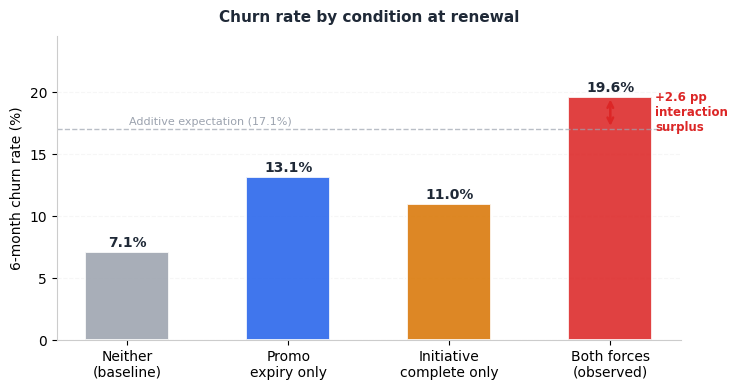

In [5]:
churn_by_cohort = customers.groupby(['promo_expired', 'initiative_complete'])['churned'].mean() * 100
labels = ['Neither\n(baseline)', 'Promo\nexpiry only',
          'Initiative\ncomplete only', 'Both forces\n(observed)']
values = [
    churn_by_cohort.loc[(0, 0)],
    churn_by_cohort.loc[(1, 0)],
    churn_by_cohort.loc[(0, 1)],
    churn_by_cohort.loc[(1, 1)],
]
expected = values[1] + values[2] - values[0]   # additive expectation
surplus  = values[3] - expected                # interaction surplus

fig, ax = plt.subplots(figsize=(7.5, 4.0))
bars = ax.bar(labels, values, color=[GRAY, BLUE, ORANGE, RED],
              width=0.52, edgecolor='white', linewidth=1.4, alpha=0.88)
for bar, val in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.4,
            f'{val:.1f}%', ha='center', fontweight='bold', color=DARK)

ax.annotate('', xy=(3, values[3]), xytext=(3, expected),
            arrowprops=dict(arrowstyle='<->', color=RED, lw=1.8))
ax.text(3.28, (values[3] + expected) / 2,
        f'+{surplus:.1f} pp\ninteraction\nsurplus',
        color=RED, fontsize=8.5, va='center', fontweight='bold')
ax.axhline(expected, color=GRAY, linestyle='--', linewidth=1, alpha=0.7)
ax.text(0.01, expected + 0.3, f'Additive expectation ({expected:.1f}%)',
        fontsize=8, color=GRAY)

ax.set_ylabel('6-month churn rate (%)')
ax.set_ylim(0, max(values) * 1.25)
ax.set_title('Churn rate by condition at renewal',
             fontsize=11, fontweight='bold', color=DARK, pad=10)
ax.yaxis.grid(True, linestyle='--', alpha=0.5); ax.set_axisbelow(True)
plt.tight_layout()
plt.savefig('figures/fig1_churn_by_condition.png', dpi=160, bbox_inches='tight')
plt.show()

## 4. Method 1: Difference-in-Differences

Triple interaction: `post * A * B`. The key coefficient is `post:A:B`,
which captures whether the price shock is amplified when initiative
completion has also occurred.

In [6]:
# 'post * A * B' expands to: post, A, B, post:A, post:B, A:B, post:A:B.
# Weighting by at_risk gives bigger cohort-weeks more influence.
did_model = smf.wls(
    'churn_rate ~ post * A * B',
    data    = panel,
    weights = panel['at_risk'],
).fit(cov_type='HC3')   # heteroskedasticity-robust standard errors

print(did_model.summary().tables[1])

# Coefficients to read:
#   post:A   = promo shock when the initiative is still ongoing
#   post:B   = initiative shock when the promo has not expired
#   post:A:B = additional churn when both forces hit in the same week
print('\nKey DiD coefficients:')
for term in ['post:A', 'post:B', 'post:A:B']:
    coef, se = did_model.params[term], did_model.bse[term]
    print(f'  {term:12s}: {coef:+.4f}  (SE {se:.4f})')

                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      0.0032      0.000     14.700      0.000       0.003       0.004
post       -7.734e-05      0.000     -0.217      0.828      -0.001       0.001
A              0.0002      0.000      0.680      0.496      -0.000       0.001
post:A         0.0026      0.001      4.922      0.000       0.002       0.004
B             -0.0004      0.000     -1.339      0.180      -0.001       0.000
post:B         0.0022      0.001      4.322      0.000       0.001       0.003
A:B          5.57e-05      0.000      0.123      0.902      -0.001       0.001
post:A:B       0.0014      0.001      1.904      0.057   -4.21e-05       0.003

Key DiD coefficients:
  post:A      : +0.0026  (SE 0.0005)
  post:B      : +0.0022  (SE 0.0005)
  post:A:B    : +0.0014  (SE 0.0007)


### Event study: parallel trends diagnostic

Restrict the panel to `initiative_complete == 0` and compute the weekly
gap between promo-expired and non-expired cohorts. Pre-renewal points
should sit near zero; post-renewal points should jump.

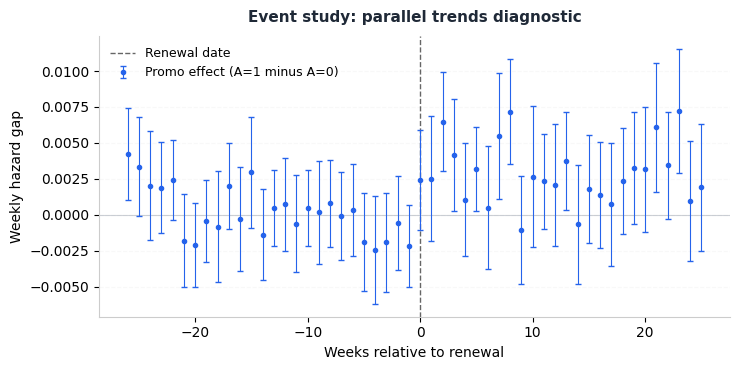

In [7]:
# Restrict to initiative_complete == 0 to isolate the promo effect
event_panel = panel[panel['B'] == 0].copy()

pivot   = event_panel.pivot_table(index='week', columns='A', values='churn_rate')
pivot_n = event_panel.pivot_table(index='week', columns='A', values='at_risk', aggfunc='sum')

def diff_se(p1, n1, p0, n0):
    """Approximate standard error for the difference of two binomial proportions."""
    return np.sqrt(p1 * (1 - p1) / np.maximum(n1, 1) +
                   p0 * (1 - p0) / np.maximum(n0, 1))

ec = pd.DataFrame({
    'week': pivot.index,
    'coef': (pivot[1] - pivot[0]).values,
    'se':   diff_se(pivot[1].values, pivot_n[1].values,
                    pivot[0].values, pivot_n[0].values),
}).sort_values('week')

fig, ax = plt.subplots(figsize=(7.5, 3.8))
ax.axvline(0, color='black', linestyle='--', linewidth=1, alpha=0.6, label='Renewal date')
ax.axhline(0, color=GRAY, linewidth=0.8, alpha=0.5)
ax.errorbar(ec['week'], ec['coef'], yerr=1.96 * ec['se'],
            fmt='o', markersize=3, color=BLUE, capsize=2,
            elinewidth=0.8, label='Promo effect (A=1 minus A=0)')
ax.set_xlabel('Weeks relative to renewal')
ax.set_ylabel('Weekly hazard gap')
ax.set_title('Event study: parallel trends diagnostic',
             fontsize=11, fontweight='bold', color=DARK, pad=10)
ax.legend(fontsize=9, framealpha=0)
ax.yaxis.grid(True, linestyle='--', alpha=0.4); ax.set_axisbelow(True)
plt.tight_layout()
plt.savefig('figures/fig2_event_study.png', dpi=160, bbox_inches='tight')
plt.show()

## 5. Method 2: Regression with interaction terms

Customer-level OLS with the full interaction. `b1` (promo_expired) is the
effect of promo expiry **when initiative_complete = 0**, not the average
effect across all customers. To get the conditional effects when the other
force is also present, add the interaction term `b3`.

In [8]:
# Customer-level regression. Outcome: 1 if customer churned within 6 months.
# np.log1p(x) = log(1 + x); used to control for skewed dollar/count covariates
# (annual revenue, seat counts) so a few large customers do not dominate.
# The * operator below expands to: main effects of A and B AND their interaction.
interaction_model = smf.ols(
    'churned ~ promo_expired * initiative_complete'
    '       + np.log1p(arr_usd) + np.log1p(n_seats)',
    data=customers,
).fit(cov_type='HC3')   # HC3 = heteroskedasticity-robust standard errors

print(interaction_model.summary().tables[1])

b1 = interaction_model.params['promo_expired']
b2 = interaction_model.params['initiative_complete']
b3 = interaction_model.params['promo_expired:initiative_complete']

print('\nConditional effects:')
print(f'  Promo expiry, initiative ongoing:     b1       = {b1:+.4f}')
print(f'  Promo expiry, initiative complete:    b1 + b3  = {b1 + b3:+.4f}')
print(f'  Initiative complete, promo ongoing:   b2       = {b2:+.4f}')
print(f'  Initiative complete, promo expired:   b2 + b3  = {b2 + b3:+.4f}')

                                        coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------------------
Intercept                             0.0140      0.046      0.303      0.762      -0.077       0.105
promo_expired                         0.0602      0.008      7.093      0.000       0.044       0.077
initiative_complete                   0.0389      0.008      4.578      0.000       0.022       0.056
promo_expired:initiative_complete     0.0262      0.013      1.999      0.046       0.001       0.052
np.log1p(arr_usd)                     0.0027      0.004      0.656      0.512      -0.005       0.011
np.log1p(n_seats)                     0.0066      0.004      1.616      0.106      -0.001       0.015

Conditional effects:
  Promo expiry, initiative ongoing:     b1       = +0.0602
  Promo expiry, initiative complete:    b1 + b3  = +0.0864
  Initiative complete, promo ongoing:   b2  

### Figure 3: Interaction visualization

Incremental churn above baseline by condition. The additive expectation
(+9 pp) is what you would predict if the two forces did not interact:
+5 pp from promo alone plus +4 pp from initiative alone. The actual joint
effect (+14 pp) overshoots that by 5 percentage points: the interaction
surplus.

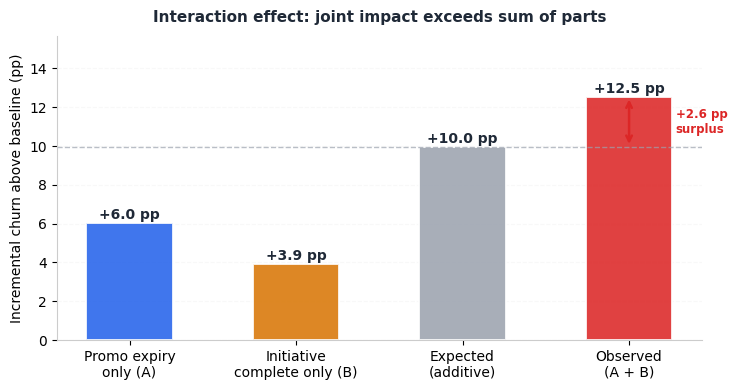

In [9]:
incremental = [
    values[1] - values[0],                  # promo only
    values[2] - values[0],                  # initiative only
    values[1] + values[2] - 2 * values[0],  # additive expectation
    values[3] - values[0],                  # observed both
]
labels3 = ['Promo expiry\nonly (A)', 'Initiative\ncomplete only (B)',
           'Expected\n(additive)', 'Observed\n(A + B)']

fig, ax = plt.subplots(figsize=(7.5, 4.0))
bars = ax.bar(labels3, incremental, color=[BLUE, ORANGE, GRAY, RED],
              width=0.52, edgecolor='white', linewidth=1.4, alpha=0.88)
for bar, val in zip(bars, incremental):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.2,
            f'+{val:.1f} pp', ha='center', fontweight='bold', color=DARK)
ax.annotate('', xy=(3, incremental[3]), xytext=(3, incremental[2]),
            arrowprops=dict(arrowstyle='<->', color=RED, lw=1.8))
ax.text(3.28, (incremental[3] + incremental[2]) / 2,
        f'+{incremental[3] - incremental[2]:.1f} pp\nsurplus',
        color=RED, fontsize=8.5, va='center', fontweight='bold')
ax.axhline(incremental[2], color=GRAY, linestyle='--', linewidth=1, alpha=0.7)
ax.set_ylabel('Incremental churn above baseline (pp)')
ax.set_ylim(0, max(incremental) * 1.25)
ax.set_title('Interaction effect: joint impact exceeds sum of parts',
             fontsize=11, fontweight='bold', color=DARK, pad=10)
ax.yaxis.grid(True, linestyle='--', alpha=0.4); ax.set_axisbelow(True)
plt.tight_layout()
plt.savefig('figures/fig3_interaction.png', dpi=160, bbox_inches='tight')
plt.show()

## 6. Method 3: Shapley value attribution

A "coalition" is any subset of drivers active together. `v(S)` is the
incremental churn caused by coalition `S`. With two drivers, each one
keeps its standalone effect, and the interaction surplus is split evenly
between them.

Promo expiry gets 5 pp + half of 5 pp = 7.5 pp.
Initiative completion gets 4 pp + the other half = 6.5 pp.

In [10]:
# Coalition values: incremental churn (pp) caused by each subset of drivers.
v = {
    frozenset():                    0,                       # neither
    frozenset(['promo']):           round(incremental[0], 1),
    frozenset(['init']):            round(incremental[1], 1),
    frozenset(['promo', 'init']):   round(incremental[3], 1),
}
print(f'Coalition values: {dict(v)}')

# 'players' = the drivers we are allocating credit across.
# For each ordering of players, each player's 'marginal contribution' is
# how much the coalition value grows when that player joins.
# Shapley value = average marginal contribution across all orderings.
def shapley_values(v, players):
    n   = len(players)
    phi = {p: 0.0 for p in players}      # accumulator for each player
    for perm in permutations(players):    # try every ordering
        coalition = frozenset()           # start with no drivers active
        for player in perm:
            # how much does the coalition value grow when this player joins?
            marginal     = v[coalition | {player}] - v[coalition]
            phi[player] += marginal
            coalition    = coalition | {player}
    # average across all n! orderings
    return {p: round(phi[p] / math.factorial(n), 2) for p in players}

phi = shapley_values(v, ['promo', 'init'])
print(f'Shapley allocation: {phi}')
print(f'Sum: {sum(phi.values()):.2f} pp  (should equal v(promo, init))')

Coalition values: {frozenset(): 0, frozenset({'promo'}): np.float64(6.0), frozenset({'init'}): np.float64(3.9), frozenset({'init', 'promo'}): np.float64(12.5)}
Shapley allocation: {'promo': np.float64(7.3), 'init': np.float64(5.2)}
Sum: 12.50 pp  (should equal v(promo, init))


### Figure 4: Coalition values + Shapley allocation

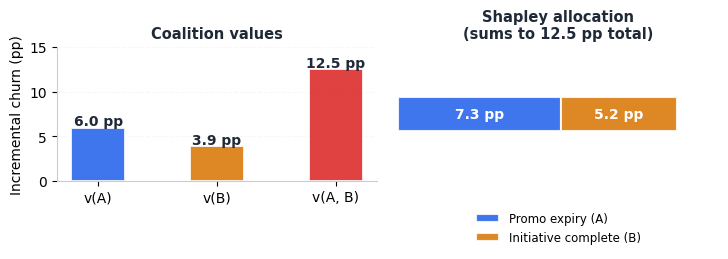

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(7.5, 3.6))

ax1 = axes[0]
cvals = [v[frozenset(['promo'])], v[frozenset(['init'])], v[frozenset(['promo','init'])]]
b3_bars = ax1.bar(['v(A)', 'v(B)', 'v(A, B)'], cvals,
                  color=[BLUE, ORANGE, RED], width=0.45,
                  edgecolor='white', linewidth=1.4, alpha=0.88)
for bar, val in zip(b3_bars, cvals):
    ax1.text(bar.get_x() + bar.get_width()/2, val + 0.2,
             f'{val:.1f} pp', ha='center', fontweight='bold', color=DARK)
ax1.set_ylabel('Incremental churn (pp)')
ax1.set_title('Coalition values', fontsize=10.5, fontweight='bold', color=DARK)
ax1.set_ylim(0, max(cvals) * 1.2)
ax1.yaxis.grid(True, linestyle='--', alpha=0.4); ax1.set_axisbelow(True)

ax2 = axes[1]
ax2.barh(0, phi['promo'], color=BLUE, height=0.4, alpha=0.88,
         edgecolor='white', linewidth=1.5, label='Promo expiry (A)')
ax2.barh(0, phi['init'], left=phi['promo'], color=ORANGE, height=0.4, alpha=0.88,
         edgecolor='white', linewidth=1.5, label='Initiative complete (B)')
ax2.text(phi['promo'] / 2, 0, f"{phi['promo']:.1f} pp", ha='center', va='center',
         color='white', fontweight='bold')
ax2.text(phi['promo'] + phi['init'] / 2, 0, f"{phi['init']:.1f} pp",
         ha='center', va='center', color='white', fontweight='bold')
ax2.set_xlim(0, (phi['promo'] + phi['init']) * 1.15)
ax2.set_ylim(-0.8, 0.8)
ax2.set_title(f"Shapley allocation\n(sums to {sum(phi.values()):.1f} pp total)",
              fontsize=10.5, fontweight='bold', color=DARK)
ax2.legend(fontsize=8.5, framealpha=0, loc='lower center',
           bbox_to_anchor=(0.5, -0.55))
ax2.axis('off')

plt.tight_layout(pad=1.5)
plt.savefig('figures/fig4_shapley.png', dpi=160, bbox_inches='tight')
plt.show()

## 7. Translating the effect into revenue and LTV

A churn coefficient is not a pricing decision. Propagate the effect
forward to a 24-month customer lifetime value (LTV) horizon and ask
whether the price increase pays for itself.

In [12]:
def ltv(monthly_churn, monthly_mrr, horizon=24):
    """
    LTV = expected revenue per customer over a fixed horizon (months).
    survival[m] = probability customer is still subscribed in month m.
    Returns undiscounted LTV. For discounted LTV, multiply by (1 + r) ** -m.
    """
    months   = np.arange(horizon)
    survival = (1 - monthly_churn) ** months
    return (survival * monthly_mrr).sum()

# Convert 6-month churn rates into monthly churn rates.
# (1 - p)^(1/6) is the monthly survival rate that compounds to (1 - p) in 6 months.
baseline_monthly = 1 - (1 - 0.08) ** (1/6)   # 0.0138 monthly churn
treated_monthly  = 1 - (1 - 0.22) ** (1/6)   # 0.0406 monthly churn

old_mrr, new_mrr = 1_000, 1_130   # 13% price increase

baseline_ltv = ltv(baseline_monthly, old_mrr)
treated_ltv  = ltv(treated_monthly,  new_mrr)

print(f'Baseline 2-year LTV: ${baseline_ltv:>10,.0f}')
print(f'Treated  2-year LTV: ${treated_ltv:>10,.0f}')
print(f'Net change:          ${treated_ltv - baseline_ltv:>10,.0f}')

# Breakeven: what new MRR would restore the baseline 2-year LTV?
price_grid = np.linspace(1_000, 1_600, 1_000)
ltv_grid   = np.array([ltv(treated_monthly, p) for p in price_grid])
breakeven  = price_grid[np.searchsorted(ltv_grid, baseline_ltv)]

print(f'\nBreakeven MRR: ${breakeven:,.0f}  '
      f'({(breakeven / old_mrr - 1) * 100:.0f}% increase vs the 13% that shipped)')

Baseline 2-year LTV: $    20,550
Treated  2-year LTV: $    17,546
Net change:          $    -3,004

Breakeven MRR: $1,324  (32% increase vs the 13% that shipped)


---

**Reading the result.** In this scenario, the 13% price increase pays for
itself in the quarter it ships but eats through medium-term customer value.
To break even on 2-year LTV at the same churn rate, the business would need
to be charging roughly $1,324, a 32% increase rather than the 13% that went
out. That gap does not close with a different price point. The underlying
use-case problem has to be addressed first.

> *The decomposition is the deliverable. The causal estimate is just the input.*